In [2]:
import numpy as np #linear algebra
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df=pd.read_csv("Social_Network_Ads.csv")

In [4]:
df=df.iloc[:,2:]

In [5]:
df.sample(5)

,Age,EstimatedSalary,Purchased
175,23,28000,0
325,41,60000,0
192,29,43000,0
360,43,129000,1
25,47,20000,1


Train Test Split

In [6]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(df.drop('Purchased',axis=1),df['Purchased'],train_size=0.8,random_state=0)
x_train.shape,y_train.shape

((320, 2), (320,))

Standard Scaler

In [7]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
scaler.fit(x_train) # it will learn the parameters

# transform train and test splits
x_train_scaler=scaler.transform(x_train)
x_test_scaler=scaler.transform(x_test)

In [8]:
scaler.mean_

array([3.8218750e+01, 6.9928125e+04])

In [9]:
x_train_scaled=pd.DataFrame(x_train_scaler,columns=x_train.columns)
y_train_scaled=pd.DataFrame(x_test_scaler,columns=x_test.columns)

In [10]:
type(x_train_scaled)

pandas.core.frame.DataFrame

In [11]:
np.round(x_train_scaled.describe(),1)

,Age,EstimatedSalary
count,320.0,320.0
mean,0.0,0.0
std,1.0,1.0
min,-2.0,-1.6
25%,-0.8,-0.8
50%,-0.0,-0.0
75%,0.8,0.5
max,2.1,2.3


Effect Of Scaling

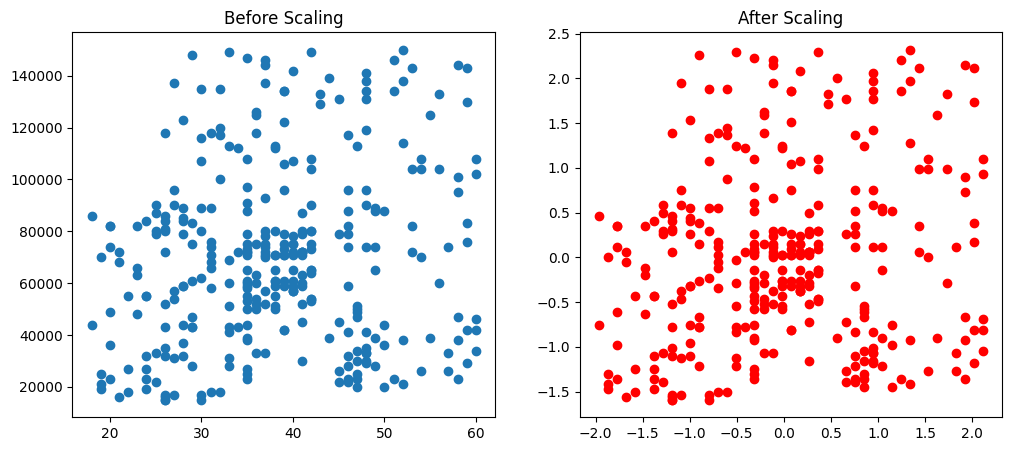

In [12]:
fig, (ax1, ax2) =plt.subplots(ncols=2, figsize=(12,5))
ax1.scatter(x_train["Age"], x_train['EstimatedSalary'])
ax1.set_title("Before Scaling")
ax2.scatter(x_train_scaled["Age"],x_train_scaled["EstimatedSalary"],color="red")
ax2.set_title("After Scaling")
plt.show()

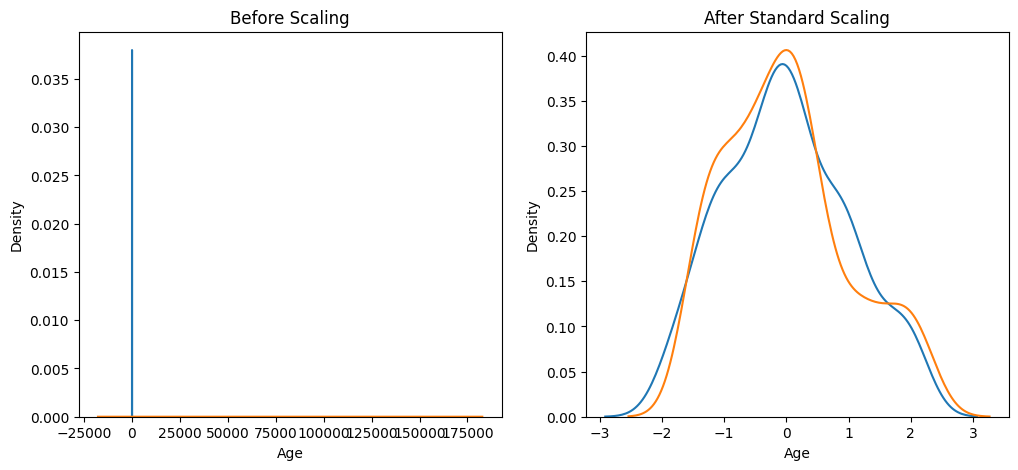

In [14]:
fig, (ax1, ax2) =plt.subplots(ncols=2, figsize=(12, 5))
#before scaling
ax1.set_title('Before Scaling')
sns.kdeplot(x_train['Age'], ax=ax1)
sns.kdeplot(x_train['EstimatedSalary'], ax=ax1)
#after scaling
ax2.set_title('After Standard Scaling')
sns.kdeplot(x_train_scaled['Age'], ax=ax2)
sns.kdeplot(x_train_scaled['EstimatedSalary'], ax=ax2)
plt.show()